# Random Forest Method Example

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure local package imports work when the notebook runs from any folder.
repo_root = Path.cwd()
while not (repo_root / "src").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
src_path = repo_root / "src"
if not src_path.exists():
    raise FileNotFoundError(f"Could not find src directory from {Path.cwd()}")
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from rice_ml.Supervised_Learning.ensemble_methods.random_forest_class import _BaseEnsemble, RandomForestClassifier, RandomForestRegressor
from rice_ml.processing.preprocessing import train_test_split, standardize
from rice_ml.processing.postprocessing import PostProcessor

# Import sklearn's plot_confusion_matrix for visualization
from sklearn.metrics import confusion_matrix

# Set the Seaborn theme
sns.set_theme()

# Reading in the Spam Email Dataset
df = pd.read_csv("../../datasets/spam_email_dataset.csv")
df.head()

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


# Data Exploration

# Preprocessing & Initialization

In [3]:
# Selecting features and target variable
features = ["num_words", "num_links", "num_attachments", "sender_reputation_score"]
target = "label"
X = df[features].values
y = df[target].values

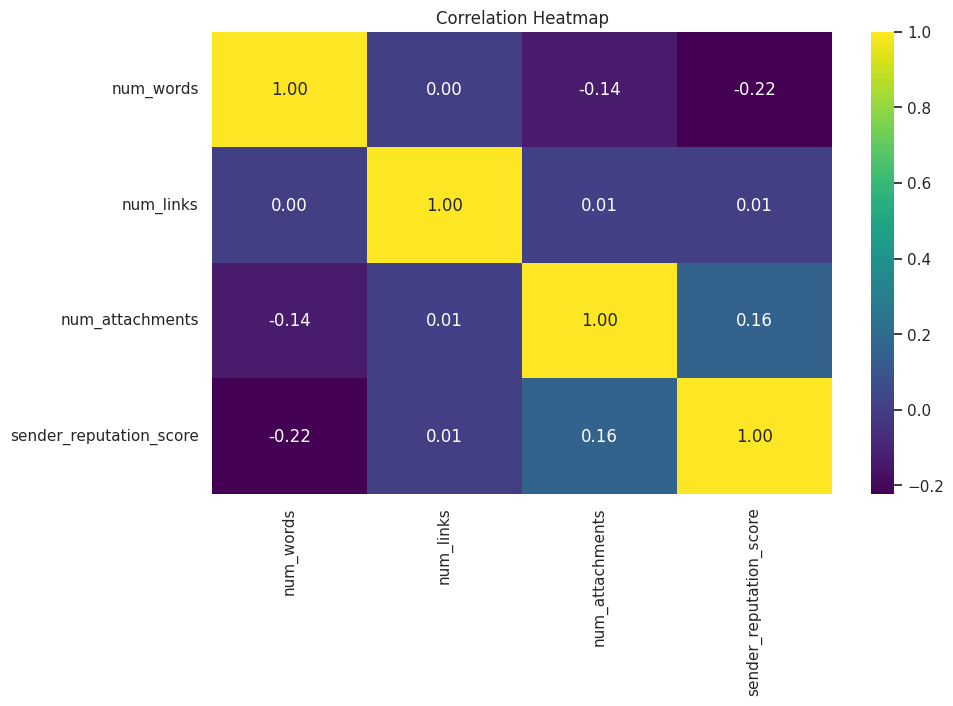

In [4]:
# Correlation heatmap of the features
corr_map = df[features].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_map, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [5]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Verifying the shapes of the splits
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

# Instantiating and train the Random Forest Classifier and Regressor
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_regressor = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_classifier.fit(X_train, y_train)
rf_regressor.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")
print("Random Forest Regressor trained successfully.")

Training features shape: (8000, 4)
Testing features shape: (2000, 4)
Training labels shape: (8000,)
Testing labels shape: (2000,)
Random Forest Classifier trained successfully.
Random Forest Regressor trained successfully.


# Prediction & Evaluation

In [ ]:
processor = PostProcessor()
# Generate predictions on the test sets for visualization
rf_classifier_predictions = rf_classifier.predict(X_test)
rf_regressor_predictions = rf_regressor.predict(X_test)

# Classification Report: Random Forest Classifier
report = processor.classification_metrics(y_test, rf_classifier_predictions)
print(f"Classification Metrics: ", report)
# Accuracy of the Random Forest Classifier
accuracy = processor.accuracy(y_test, rf_classifier_predictions)

# Regression Report: Random Forest Regressor
reg_report = processor.regression_metrics(y_test, rf_regressor_predictions)
print(f"Regression Metrics: ", reg_report)

Classification Metrics:  {'classification_error': 0.396, 'precision': 0.0, 'confusion_matrix': array([[1208,    0],
       [ 792,    0]])}
Regression Metrics:  {'mae': 0.21684877795377466, 'mse': 0.11097737114136005, 'rmse': 0.3331326629758182, 'r2': 0.536016743840056, 'sst': 478.36800000000005, 'ssr': 256.41325771728, 'sse': 221.9547422827201, 'df_regression': 1.0, 'df_error': 1998.0, 'df_total': 1999.0, 'ms_regression': 256.41325771728, 'ms_error': 0.11108845960096102, 'f_statistic': 2308.1898753330247}
